# Hospital Operations & Patient Analytics

## Business Problem
The hospital manages tens of thousands of patient encounters every year across several care settings (ambulatory, outpatient, wellness, urgent care, emergency and inpatient), each billed through different payers or with no insurance at all. Management currently lacks a consolidated view of **how patient volume is changing, which services drive cost, how much of that cost is actually covered by payers, and which patients keep returning shortly after discharge**. Without this view it is hard to plan capacity, control costs, protect revenue and improve quality of care.

## Objective of the Project
Using four datasets (encounters, patients, procedures, payers), this project aims to:
1. **Understand encounter trends** - yearly volume, mix of encounter classes and length of stay.
2. **Analyse cost and coverage** - share of encounters with zero payer coverage, most frequent and most expensive procedures, and average claim cost by payer.
3. **Study patient behaviour** - quarterly inpatient admissions, 30-day readmissions, and the demographic profile (age group, city, race, gender, marital status) of the patient base.
4. **Turn the findings into actionable recommendations** for capacity planning, revenue protection and readmission reduction.

---


## Data Loading & Setup



In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
!gdown 1ynq39Eme6nY-wEhM-GThSFBQ4qm4NQAO
!gdown 1zvgn5nwy6xMrpDHqJVDFIaSIHuSGjHWt
!gdown 1c8CkP7PR3YCfTvMpUe_ou_sneesp8BAi
!gdown 1BJWlvE3dquZiK3EOjwvPsg8sjRaZU8b9


Downloading...
From: https://drive.google.com/uc?id=1ynq39Eme6nY-wEhM-GThSFBQ4qm4NQAO
To: /content/encounters.csv
100% 7.65M/7.65M [00:00<00:00, 32.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zvgn5nwy6xMrpDHqJVDFIaSIHuSGjHWt
To: /content/patients.csv
100% 221k/221k [00:00<00:00, 17.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1c8CkP7PR3YCfTvMpUe_ou_sneesp8BAi
To: /content/payers.csv
100% 1.03k/1.03k [00:00<00:00, 4.12MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BJWlvE3dquZiK3EOjwvPsg8sjRaZU8b9
To: /content/procedures.csv
100% 8.71M/8.71M [00:00<00:00, 63.4MB/s]


In [3]:
df_encounter = pd.read_csv('/content/encounters.csv')
df_patient = pd.read_csv('/content/patients.csv')
df_payers = pd.read_csv('/content/payers.csv')
df_procedures = pd.read_csv('/content/procedures.csv')

## Data Understanding & Quality Checks


In [4]:
df_encounter.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [5]:
df_encounter.shape

(27891, 14)

In [6]:
df_encounter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27891 entries, 0 to 27890
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   27891 non-null  object 
 1   START                27891 non-null  object 
 2   STOP                 27891 non-null  object 
 3   PATIENT              27891 non-null  object 
 4   ORGANIZATION         27891 non-null  object 
 5   PAYER                27891 non-null  object 
 6   ENCOUNTERCLASS       27891 non-null  object 
 7   CODE                 27891 non-null  int64  
 8   DESCRIPTION          27891 non-null  object 
 9   BASE_ENCOUNTER_COST  27891 non-null  float64
 10  TOTAL_CLAIM_COST     27891 non-null  float64
 11  PAYER_COVERAGE       27891 non-null  float64
 12  REASONCODE           8350 non-null   float64
 13  REASONDESCRIPTION    8350 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 3.0+ MB


In [7]:
df_encounter.duplicated().sum()

np.int64(0)

In [8]:
df_encounter.describe(include='object').T

,count,unique,top,freq
Id,27891,27891,64dfd3ce-7123-fa23-ec24-f74b492553e2,1
START,27891,27541,2016-12-08T10:00:40Z,3
STOP,27891,27765,2016-12-08T10:15:40Z,3
PATIENT,27891,974,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381
ORGANIZATION,27891,1,d78e84ec-30aa-3bba-a33a-f29a3a454662,27891
PAYER,27891,10,7caa7254-5050-3b5e-9eae-bd5ea30e809c,11371
ENCOUNTERCLASS,27891,6,ambulatory,12537
DESCRIPTION,27891,53,Encounter for problem (procedure),4308
REASONDESCRIPTION,8350,73,Chronic congestive heart failure (disorder),1738


In [9]:
df_encounter.isna().sum()

,0
Id,0
START,0
STOP,0
PATIENT,0
ORGANIZATION,0
PAYER,0
ENCOUNTERCLASS,0
CODE,0
DESCRIPTION,0
BASE_ENCOUNTER_COST,0


In [10]:
df_encounter.describe()

,CODE,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE
count,2.789100e+04,27891.000000,27891.000000,27891.000000,8.350000e+03
mean,2.972670e+08,116.181614,3639.682174,1114.965652,4.751643e+11
std,2.017839e+08,28.410082,9205.595748,4768.615576,5.874089e+12
min,1.505002e+06,85.550000,0.000000,0.000000,5.602001e+06
25%,1.853450e+08,85.550000,142.580000,0.000000,5.582200e+07
50%,1.853490e+08,136.800000,278.580000,28.440000,8.880501e+07
75%,4.244410e+08,142.580000,1412.530000,155.770000,1.956620e+08
max,7.029270e+08,146.180000,641882.700000,247751.420000,1.241710e+14


In [11]:
# Change Date format from object to datetime
df_encounter['START'] = pd.to_datetime(df_encounter['START'])
df_encounter['STOP'] = pd.to_datetime(df_encounter['STOP'])


In [12]:
df_patient.head()

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,hispanic,M,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,hispanic,M,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813


In [13]:
df_patient.shape

(974, 20)

In [14]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PREFIX      974 non-null    object 
 4   FIRST       974 non-null    object 
 5   LAST        974 non-null    object 
 6   SUFFIX      21 non-null     object 
 7   MAIDEN      386 non-null    object 
 8   MARITAL     973 non-null    object 
 9   RACE        974 non-null    object 
 10  ETHNICITY   974 non-null    object 
 11  GENDER      974 non-null    object 
 12  BIRTHPLACE  974 non-null    object 
 13  ADDRESS     974 non-null    object 
 14  CITY        974 non-null    object 
 15  STATE       974 non-null    object 
 16  COUNTY      974 non-null    object 
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON         974 non-null    f

In [15]:
df_patient.duplicated().sum()

np.int64(0)

In [16]:
df_patient.describe(include='object').T

,count,unique,top,freq
Id,974,974,204f8028-72f8-d6f8-761f-79ebf9f02311,1
BIRTHDATE,974,880,1927-04-22,4
DEATHDATE,154,148,2017-09-29,2
PREFIX,974,3,Mr.,494
FIRST,974,842,Gregorio366,3
LAST,974,498,Heaney114,6
SUFFIX,21,3,PhD,10
MAIDEN,386,279,Jerde200,5
MARITAL,973,2,M,784
RACE,974,6,white,680


In [17]:
df_patient['BIRTHDATE'] = pd.to_datetime(df_patient['BIRTHDATE'])
df_patient['DEATHDATE'] = pd.to_datetime(df_patient['DEATHDATE'])

In [18]:
df_procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05T12:58:36Z,2011-01-05T16:42:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


In [19]:
df_procedures.shape

(47701, 9)

In [20]:
df_procedures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47701 entries, 0 to 47700
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   START              47701 non-null  object 
 1   STOP               47701 non-null  object 
 2   PATIENT            47701 non-null  object 
 3   ENCOUNTER          47701 non-null  object 
 4   CODE               47701 non-null  int64  
 5   DESCRIPTION        47701 non-null  object 
 6   BASE_COST          47701 non-null  int64  
 7   REASONCODE         10756 non-null  float64
 8   REASONDESCRIPTION  10756 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 3.3+ MB


In [21]:
df_procedures.nunique()

,0
START,39251
STOP,42263
PATIENT,793
ENCOUNTER,14670
CODE,157
DESCRIPTION,163
BASE_COST,8268
REASONCODE,46
REASONDESCRIPTION,46


In [22]:
df_procedures.isna().sum()

,0
START,0
STOP,0
PATIENT,0
ENCOUNTER,0
CODE,0
DESCRIPTION,0
BASE_COST,0
REASONCODE,36945
REASONDESCRIPTION,36945


In [23]:
df_procedures.duplicated().sum()

np.int64(0)

In [24]:
df_procedures['START'] = pd.to_datetime(df_procedures['START'])
df_procedures['STOP'] = pd.to_datetime(df_procedures['STOP'])

In [25]:
df_payers

,Id,NAME,ADDRESS,CITY,STATE_HEADQUARTERED,ZIP,PHONE
0,b3221cfc-24fb-339e-823d-bc4136cbc4ed,Dual Eligible,7500 Security Blvd,Baltimore,MD,21244.0,1-877-267-2323
1,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,21244.0,1-800-633-4227
2,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,Medicaid,7500 Security Blvd,Baltimore,MD,21244.0,1-877-267-2323
3,d47b3510-2895-3b70-9897-342d681c769d,Humana,500 West Main St,Louisville,KY,40018.0,1-844-330-7799
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,Blue Cross Blue Shield,Michigan Plaza,Chicago,IL,60007.0,1-800-262-2583
5,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,UnitedHealthcare,9800 Healthcare Lane,Minnetonka,MN,55436.0,1-888-545-5205
6,4d71f845-a6a9-3c39-b242-14d25ef86a8d,Aetna,151 Farmington Ave,Hartford,CT,6156.0,1-800-872-3862
7,047f6ec3-6215-35eb-9608-f9dda363a44c,Cigna Health,900 Cottage Grove Rd,Bloomfield,CT,6002.0,1-800-997-1654
8,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,Anthem,220 Virginia Ave,Indianapolis,IN,46204.0,1-800-331-1476
9,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,NaN,NaN,NaN,NaN,NaN


In [26]:
df_payers.shape

(10, 7)

In [27]:
df_payers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   10 non-null     object 
 1   NAME                 10 non-null     object 
 2   ADDRESS              9 non-null      object 
 3   CITY                 9 non-null      object 
 4   STATE_HEADQUARTERED  9 non-null      object 
 5   ZIP                  9 non-null      float64
 6   PHONE                9 non-null      object 
dtypes: float64(1), object(6)
memory usage: 692.0+ bytes


##  ENCOUNTERS OVERVIEW

###  Total Encounters per Year


QUESTION A. How many total encounters occurred each year?

In [28]:
df_encounter['YEAR']= df_encounter['START'].dt.year

In [29]:
yr = df_encounter['YEAR'].value_counts().reset_index()
yr

,YEAR,count
0,2014,3885
1,2021,3530
2,2020,2519
3,2013,2495
4,2015,2469
5,2016,2451
6,2017,2360
7,2018,2292
8,2019,2228
9,2012,2106


In [30]:
df_encounter['START'].max()

Timestamp('2022-02-05 20:27:36+0000', tz='UTC')

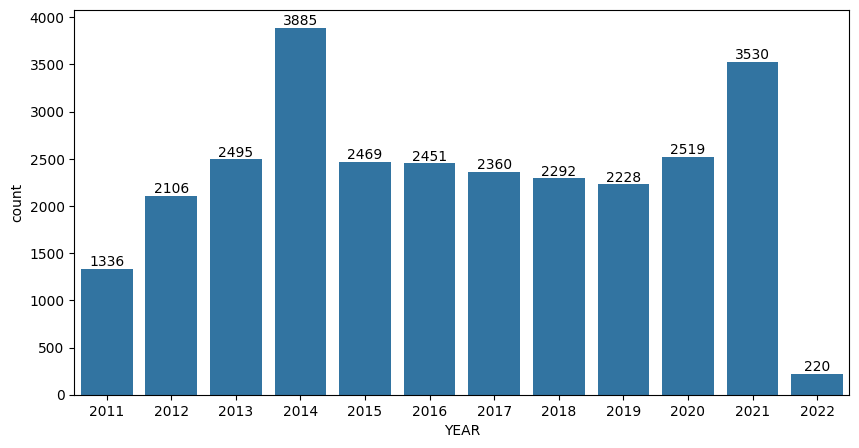

In [31]:
plt.figure(figsize=(10,5))
a = sns.barplot(x=yr['YEAR'],y= yr['count'])
for i in a.containers:
  a.bar_label(i)
plt.show()

In 2014 has the highest no. of encounter recorded 3385. In 2020 we have data till feburary so we will not consider it. overall no. of encounter remain stable.

###  Encounter Class Mix by Year (%)


QUESTION B. For each year, what percentage of all encounters belonged to each encounter class
-- (ambulatory, outpatient, wellness, urgent care, emergency, and inpatient)?

In [32]:
class_order = pd.crosstab(index=df_encounter['YEAR'],columns=df_encounter['ENCOUNTERCLASS'],normalize='index',margins=True).mul(100)
class_order

ENCOUNTERCLASS,ambulatory,emergency,inpatient,outpatient,urgentcare,wellness
YEAR,,,,,,
2011,49.925150,4.116766,6.212575,24.476048,2.245509,13.023952
2012,42.497626,8.689459,4.415954,21.082621,14.197531,9.116809
2013,44.328657,9.018036,5.370741,19.438878,14.388778,7.454910
2014,60.257400,5.559846,3.037323,17.863578,8.416988,4.864865
2015,43.458890,9.234508,4.495747,20.494127,15.390846,6.925881
2016,43.778050,10.199918,5.059160,19.624643,13.912689,7.425541
2017,41.822034,9.237288,5.338983,20.127119,16.313559,7.161017
2018,40.706806,10.776614,3.534031,20.942408,16.448517,7.591623
2019,37.971275,10.188510,6.014363,20.466786,17.818671,7.540395


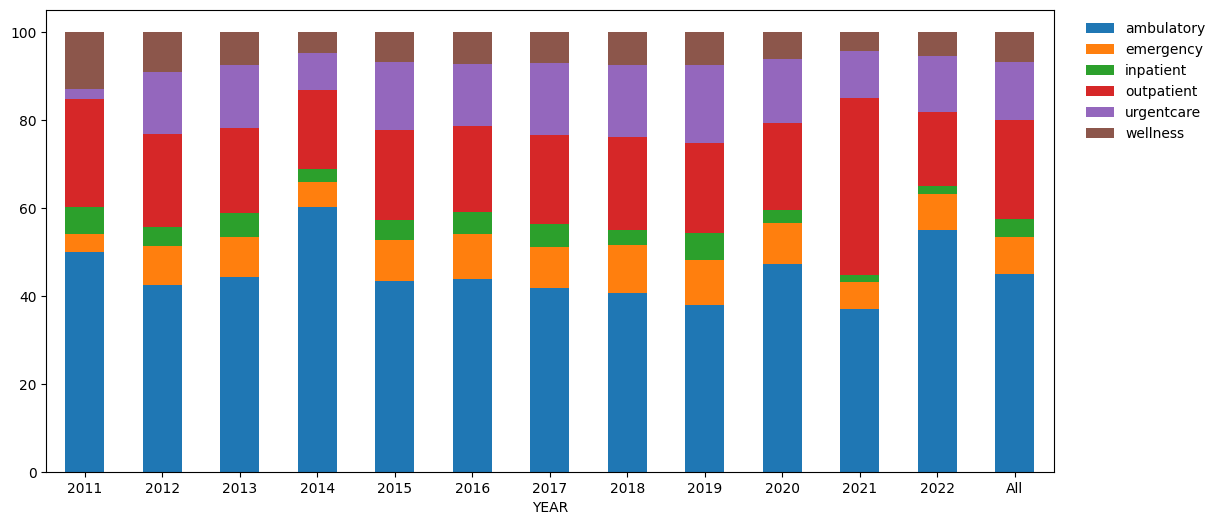

In [33]:
class_order.plot(kind='bar',stacked=True,figsize=(13,6))
plt.xticks(rotation=0)
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Ambulatory and outpatient visits consistently form the vast majority of all healthcare encounters across every recorded year from 2011 to 2022.

###  Encounters Over 24 Hours vs Under 24 Hours


 QUESTION C. What percentage of encounters were over 24 hours versus under 24 hours?

In [34]:
df_encounter['duration_hours'] =  ((df_encounter['STOP'] - df_encounter['START']).dt.total_seconds()/3600).round(2)

df_encounter['duration_category']= np.where(df_encounter['duration_hours']> 24,'Over 24 hours','under 24 hours')

final_table = df_encounter['duration_category'].value_counts(normalize=True).mul(100).reset_index(name='percentage')
final_table

,duration_category,percentage
0,under 24 hours,99.731096
1,Over 24 hours,0.268904


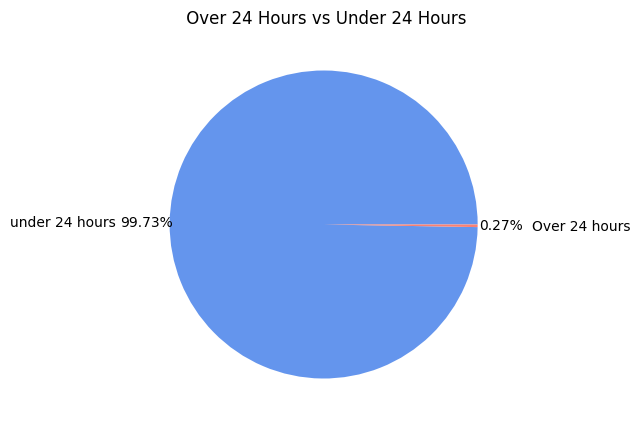

,count
duration_category,
under 24 hours,27816
Over 24 hours,75


In [35]:
plt.figure(figsize=(5, 5))

plt.pie(final_table['percentage'],labels=final_table['duration_category'],autopct='%.2f%%', pctdistance=1.15, labeldistance=1.35, colors=['cornflowerblue','salmon'])

plt.title(' Over 24 Hours vs Under 24 Hours')
plt.show()

display(df_encounter['duration_category'].value_counts())

majority of patient visits lasted less than a full day.

## OBJECTIVE 2: COST & COVERAGE INSIGHTS

###  Encounters with Zero Payer Coverage


 A. How many encounters had zero payer coverage, and what percentage of total encounters does this represent?

In [36]:
df_encounter.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,YEAR,duration_hours,duration_category
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02 09:26:36+00:00,2011-01-02 12:58:36+00:00,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN,2011,3.53,under 24 hours
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03 05:44:39+00:00,2011-01-03 06:01:42+00:00,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN,2011,0.28,under 24 hours
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03 14:32:11+00:00,2011-01-03 14:47:11+00:00,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN,2011,0.25,under 24 hours
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03 16:24:45+00:00,2011-01-03 16:39:45+00:00,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN,2011,0.25,under 24 hours
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03 17:36:53+00:00,2011-01-03 17:51:53+00:00,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia,2011,0.25,under 24 hours


In [37]:
df_encounter['is_zero_coverage']  = np.where(df_encounter['PAYER_COVERAGE'] == 0, 'Zero Coverage', 'Has Coverage')

In [38]:
zero_tabel = df_encounter['is_zero_coverage'].value_counts(normalize=True).mul(100).reset_index(name='percentage')
zero_tabel

,is_zero_coverage,percentage
0,Has Coverage,51.288946
1,Zero Coverage,48.711054


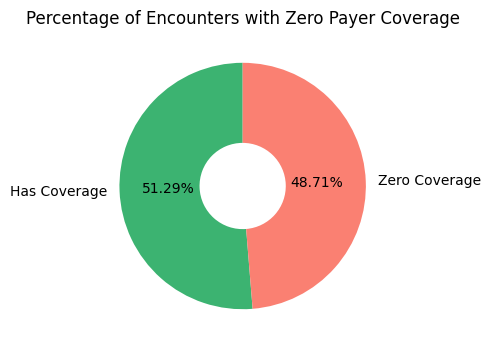

In [39]:
plt.figure(figsize=(4, 4))

plt.pie(zero_tabel['percentage'], labels=zero_tabel['is_zero_coverage'], autopct='%.2f%%',startangle=90,wedgeprops={'width': 0.65},
        colors=['mediumseagreen','salmon'])

plt.title('Percentage of Encounters with Zero Payer Coverage')
plt.show()

early half of all hospital visits (48.71%) received zero insurance coverage.

### Claimed vs Unclaimed Cost

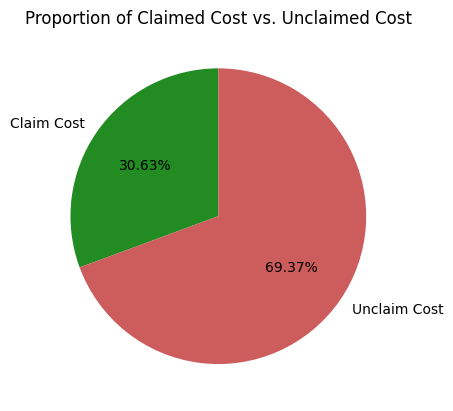

Total Claim Cost: $101,514,375.52
Claimed Cost: $31,097,506.99
Unclaimed Cost: $70,416,868.53 (69.0%) of Total Claimed


In [40]:
total_claimed = df_encounter['TOTAL_CLAIM_COST'].sum().round(2)

claimed_cost = df_encounter['PAYER_COVERAGE'].sum().round(2)
unclaimed_cost = total_claimed -  claimed_cost
unclaimed_pct = round(unclaimed_cost/total_claimed,2)*100
unclaimed_pct

sizes = [claimed_cost,unclaimed_cost]
label = ['Claim Cost','Unclaim Cost']

plt.pie(sizes,labels=label, autopct='%.2f%%',startangle=90,colors=['forestgreen','indianred'])
plt.title('Proportion of Claimed Cost vs. Unclaimed Cost')
plt.show()
print(f'Total Claim Cost: ${total_claimed:,.2f}')
print(f'Claimed Cost: ${claimed_cost:,.2f}')
print(f'Unclaimed Cost: ${unclaimed_cost:,.2f} ({unclaimed_pct}%) of Total Claimed')

<Axes: >

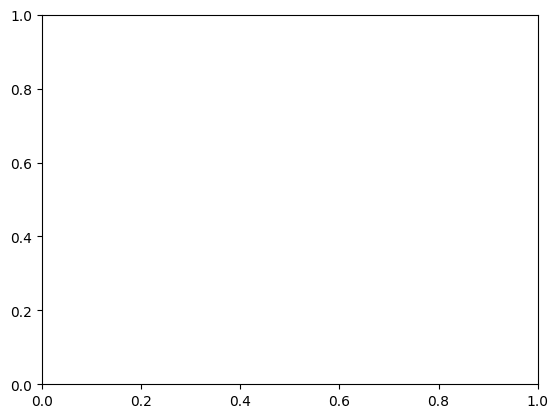

In [41]:
sns.lineplot()

###  Top 10 Most Frequent Procedures and Their Average Base Cost


 B. What are the top 10 most frequent procedures performed and the average base cost for each?

In [42]:
proc_summary = df_procedures.groupby('DESCRIPTION').agg(procedure_count = ('ENCOUNTER','count'),
                                                        av_base_cost= ('BASE_COST','mean')).reset_index()
proc_summary['av_base_cost'] = proc_summary['av_base_cost'].round(4)

top_10_frequent = proc_summary.sort_values(by='procedure_count',ascending=False).head(10).reset_index()
top_10_frequent

,index,DESCRIPTION,procedure_count,av_base_cost
0,11,Assessment of health and social care needs (pr...,4596,431.0000
1,69,Hospice care (regime/therapy),4098,431.0000
2,46,Depression screening using Patient Health Ques...,3614,431.0000
3,44,Depression screening (procedure),3614,431.0000
4,12,Assessment of substance use (procedure),2906,431.0000
5,124,Renal dialysis (procedure),2746,1004.0863
6,14,Assessment using Morse Fall Scale (procedure),2422,431.0000
7,10,Assessment of anxiety (procedure),2288,431.0000
8,95,Medication Reconciliation (procedure),2284,509.1243
9,132,Screening for drug abuse (procedure),1484,431.0000


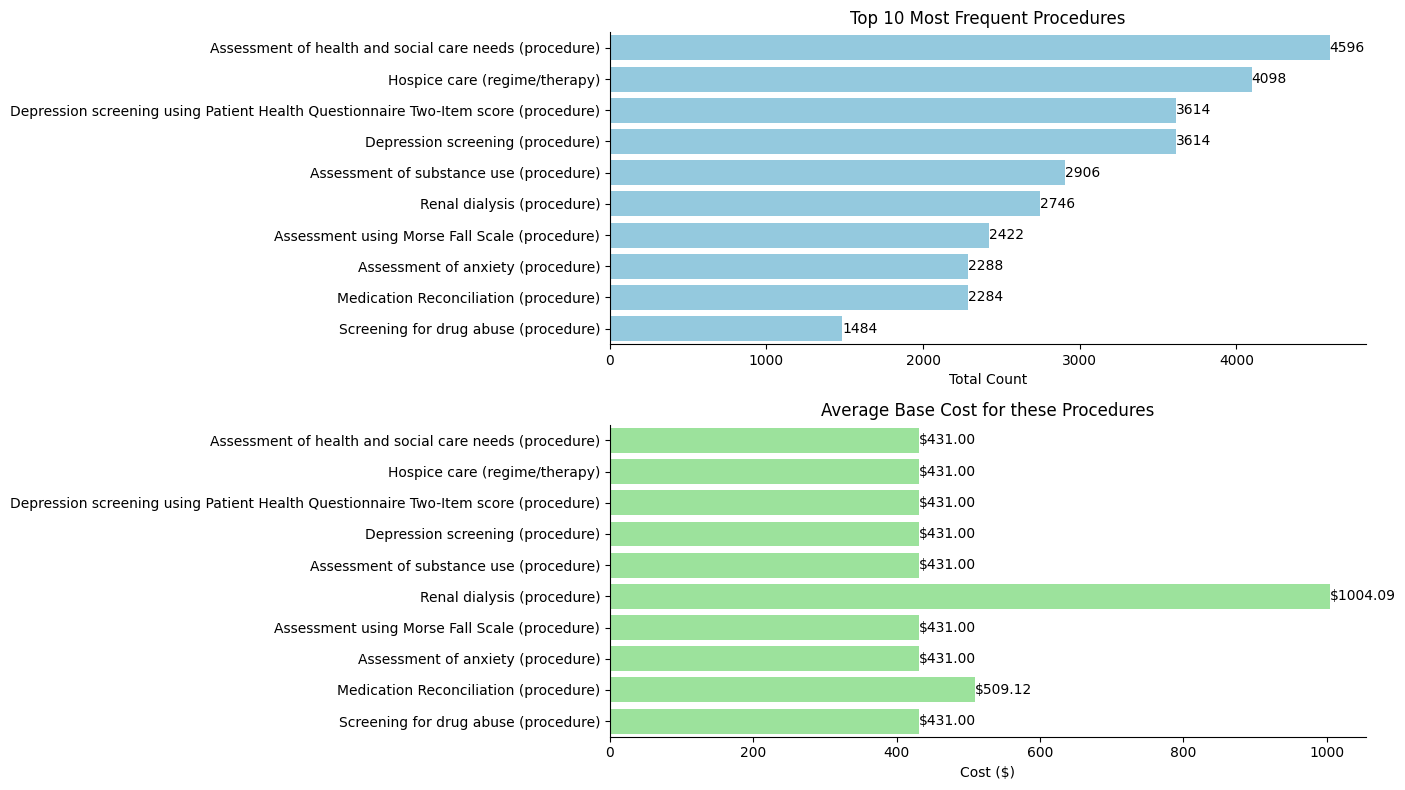

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

a = sns.barplot(data=top_10_frequent, x='procedure_count', y='DESCRIPTION', ax=axes[0], color='skyblue')
for i in a.containers:
  a.bar_label(i)
axes[0].set_title('Top 10 Most Frequent Procedures')
axes[0].set_xlabel('Total Count')
axes[0].set_ylabel('')


b= sns.barplot(data=top_10_frequent, x='av_base_cost', y='DESCRIPTION', ax=axes[1], color='lightgreen')
for i in b.containers:
  b.bar_label(i,fmt='$%.2f')
axes[1].set_title('Average Base Cost for these Procedures')
axes[1].set_xlabel('Cost ($)')
axes[1].set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

- "Assessment of health and social care needs" is the most frequently performed procedure, with a total count of 4,596.  
- While eight of the top ten most common procedures share a standard average base cost of \$431.00, renal dialysis is a significant outlier, costing more than double at $1004.09 despite having 2746 procedures.

###  Top 10 Procedures by Highest Average Base Cost


C. What are the top 10 procedures with the highest average base cost and the number of times they were performed?

In [44]:
top_10_avg_base_cost = proc_summary.sort_values(by='av_base_cost',ascending=False).head(10).reset_index()
top_10_avg_base_cost

,index,DESCRIPTION,procedure_count,av_base_cost
0,4,Admit to ICU (procedure),5,206260.4000
1,39,Coronary artery bypass grafting,9,47085.8889
2,86,Lumpectomy of breast (procedure),5,29353.0000
3,64,Hemodialysis (procedure),27,29299.5556
4,76,Insertion of biventricular implantable cardiov...,4,27201.0000
5,50,Electrical cardioversion,1383,25903.1106
6,103,Partial resection of colon,7,25229.2857
7,60,Fine needle aspiration biopsy of lung (procedure),1,23141.0000
8,107,Percutaneous mechanical thrombectomy of portal...,57,20228.0351
9,106,Percutaneous coronary intervention,9,19728.0000


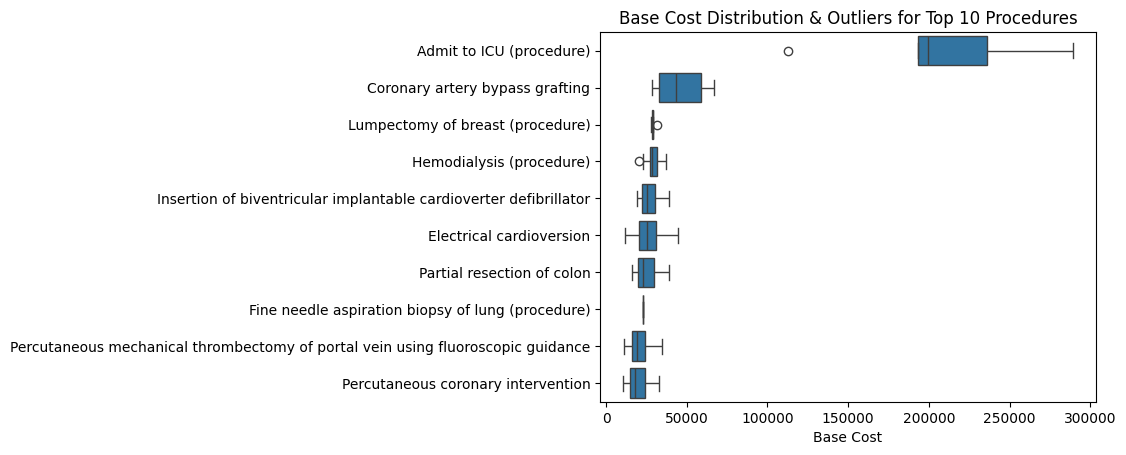

In [45]:
top_10_proc_df = df_procedures[df_procedures['DESCRIPTION'].isin(top_10_avg_base_cost['DESCRIPTION'].to_list())]

sns.boxplot(top_10_proc_df, y = 'DESCRIPTION', x='BASE_COST',order = top_10_avg_base_cost['DESCRIPTION'].to_list())
plt.title('Base Cost Distribution & Outliers for Top 10 Procedures')
plt.xlabel('Base Cost')
plt.ylabel('')
plt.show()

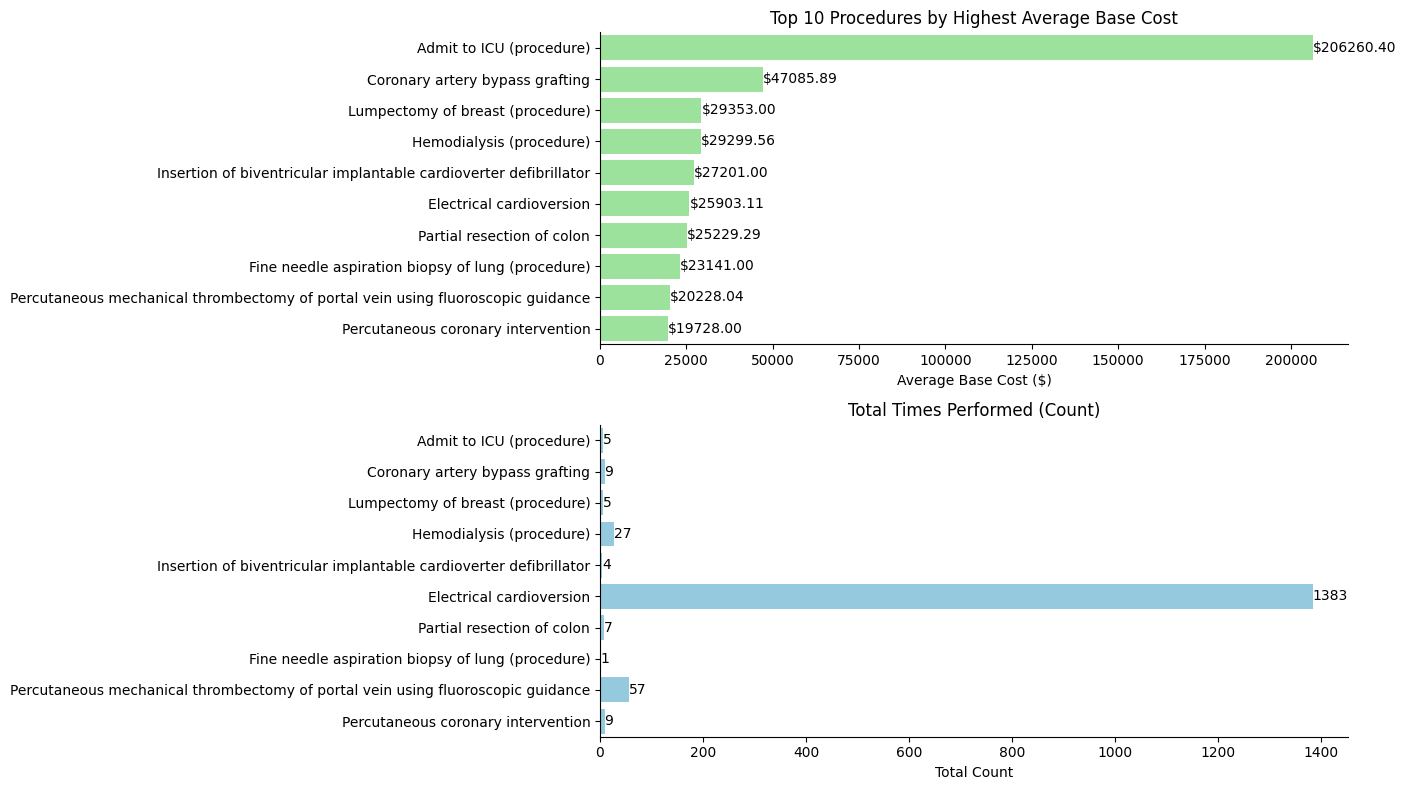

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

a = sns.barplot(data=top_10_avg_base_cost, x='av_base_cost', y='DESCRIPTION', ax=axes[0], color='lightgreen')
for i in a.containers:
  a.bar_label(i,fmt='$%.2f')
axes[0].set_title('Top 10 Procedures by Highest Average Base Cost')
axes[0].set_xlabel('Average Base Cost ($)')
axes[0].set_ylabel('')


b= sns.barplot(data=top_10_avg_base_cost, x='procedure_count', y='DESCRIPTION', ax=axes[1], color='skyblue')
for i in b.containers:
  b.bar_label(i)
axes[1].set_title('Total Times Performed (Count)')
axes[1].set_xlabel('Total Count')
axes[1].set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

- "Admit to ICU" is the most expensive procedure by a wide margin at \$206,260.40, though it was only performed 5 times.   
- While most of the top ten highest-cost procedures are rarely performed, "Electrical cardioversion" is a significant outlier, occurring 1,383 times despite its $25,903.11 average base cost.

###  Average Total Claim Cost by Payer


D. What is the average total claim cost for encounters, broken down by payer?

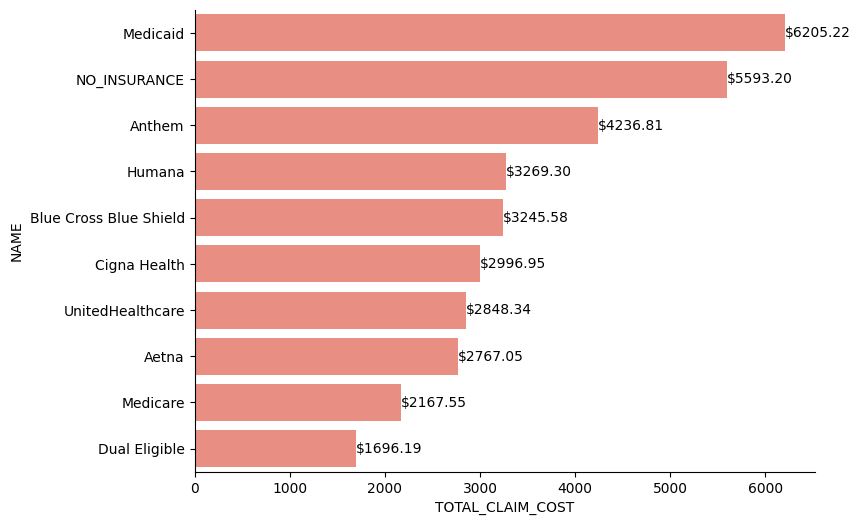

In [47]:
df_encounter_x_payer = df_encounter.merge(df_payers, how='left', left_on='PAYER', right_on='Id',suffixes=('_encounter','_payers'))

payers_tabel = df_encounter_x_payer.groupby('NAME')['TOTAL_CLAIM_COST'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,6))
a = sns.barplot(data=payers_tabel, y='NAME', x='TOTAL_CLAIM_COST', color='salmon')
for i in a.containers:
  a.bar_label(i,fmt='$%.2f')
sns.despine()
plt.show()

- Medicaid accounts for the highest total claim cost \$6,205
- Patients with no insurance (No Insurance) represent the second-highest financial burden with total claim costs reaching \$5,593.

## PATIENT BEHAVIOR ANALYSIS

### Unique Inpatients Admitted per Quarter


A. How many unique patients were admitted each quarter over time?

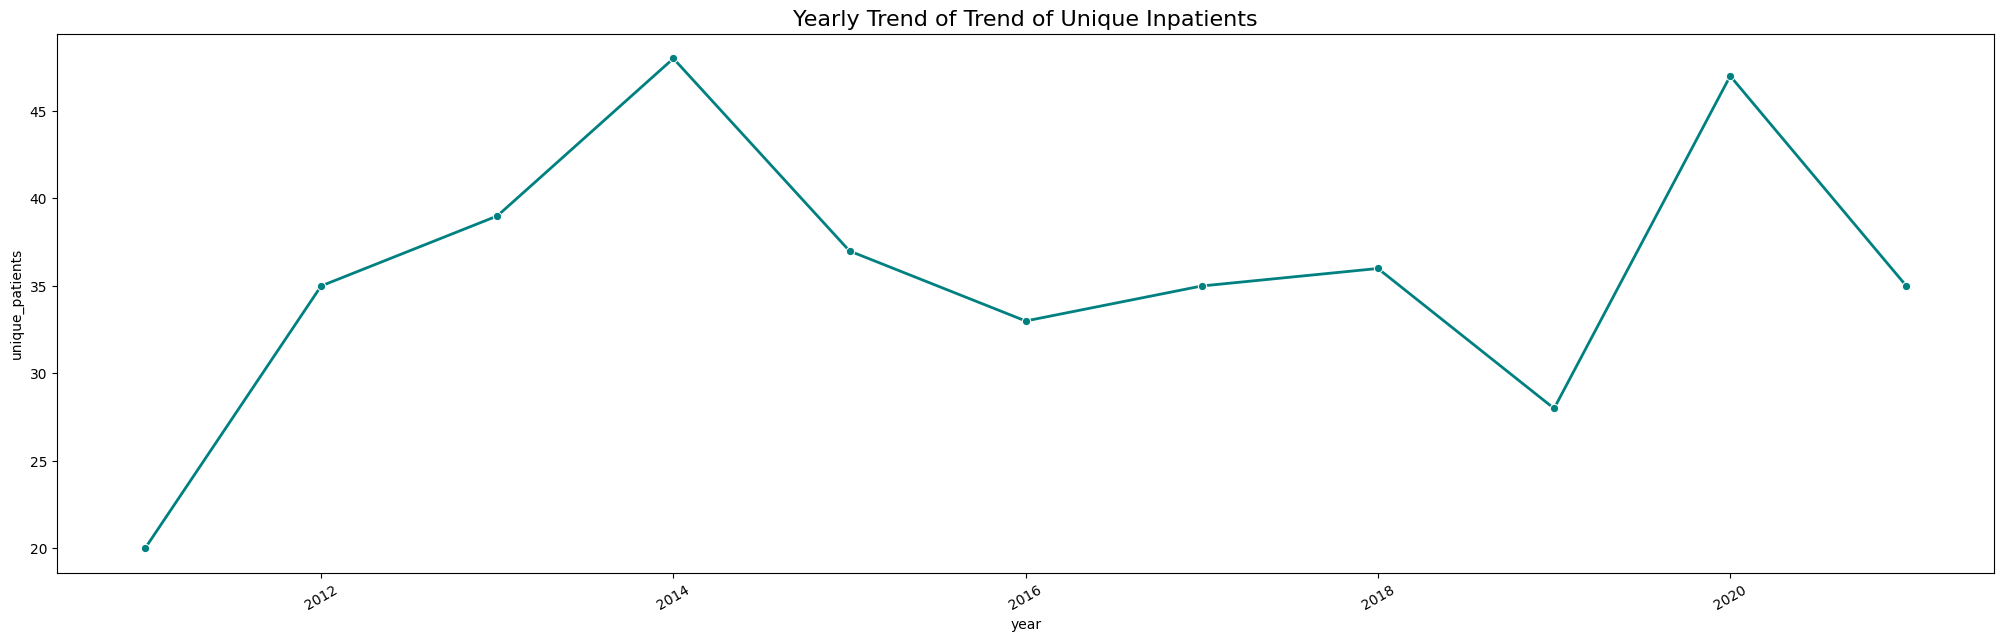

In [48]:
inpatient = df_encounter[df_encounter['ENCOUNTERCLASS']=='inpatient'].copy()

inpatient['year'] = inpatient['START'].dt.year

inpatient_till_2021 = inpatient[inpatient['year']!=2022] # removeing 2022 becuse we have only 2 months of data which will affect the output
unique_patients_qtr = inpatient_till_2021.groupby('year')['PATIENT'].nunique().reset_index(name='unique_patients')


plt.figure(figsize=(25,7))
sns.lineplot(data= unique_patients_qtr, x='year', y= 'unique_patients', marker='o',linewidth=2,color='teal')
plt.title('Yearly Trend of Trend of Unique Inpatients',fontsize=16)
plt.xticks(rotation=30)
plt.show()

Patient volume hit its highest peaks of 48 patient in 2014 and in 2019 after hitting it's lowest 28 patient in 2019.

### 30-Day Readmissions


B. How many patients were readmitted within 30 days of a previous encounter?

In [49]:
df = df_encounter[df_encounter['ENCOUNTERCLASS']=='inpatient'].copy()


df['START'] = pd.to_datetime(df['START'], utc=True)
df['STOP']  = pd.to_datetime(df['STOP'],  utc=True)
df['days']  = (df['STOP'] - df['START']).dt.total_seconds() / 86400

adm = df[df['days'] >= 0.5].sort_values(['PATIENT', 'START']).copy()   # 12 hours or more
adm['prev_stop'] = adm.groupby('PATIENT')['STOP'].shift(1)
gap = (adm['START'].dt.normalize() - adm['prev_stop'].dt.normalize()).dt.days

is_readmit = (gap > 1) & (gap <= 30)
is_initial = gap.isna() | (gap > 30)

n_adm     = len(adm)
n_initial = is_initial.sum()
n_readmit = is_readmit.sum()
total_patients = adm['PATIENT'].nunique()
readmitted_patients = adm.loc[is_readmit, 'PATIENT'].nunique()
Readmission_rate = n_readmit/n_initial

print("Total Patients:", total_patients)
print("Readmitted patients:", readmitted_patients)

print('\n')
print("Admissions:", n_adm)
print("Initial:", n_initial)
print("Readmissions:", n_readmit)

print(f"Readmission Rate: {Readmission_rate:.1%}")

Total Patients: 153
Readmitted patients: 23


Admissions: 1135
Initial: 554
Readmissions: 266
Readmission Rate: 48.0%


23 Patient were readmitted within 30 days after getting discharge.
The readmission rate is around 48%

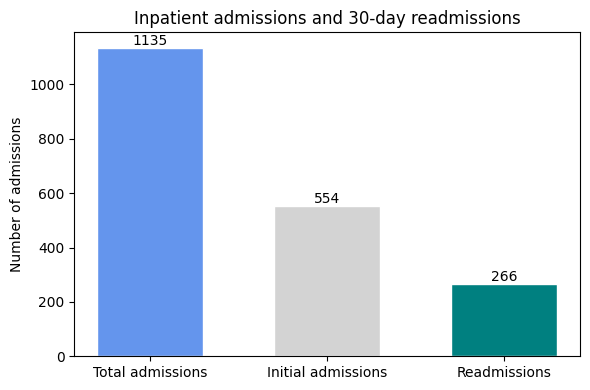

In [50]:
labels = ['Total admissions', 'Initial admissions', 'Readmissions']
values = [n_adm, n_initial, n_readmit]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, edgecolor='white', width=0.6,color = ['cornflowerblue', 'lightgray', 'teal'])
ax.bar_label(bars)
ax.set_ylabel('Number of admissions')
ax.set_title('Inpatient admissions and 30-day readmissions')
plt.tight_layout()
plt.show()

###  Patient Age Distribution and Age Groups


Feature Engineering creating age field in patient table

In [51]:
preferance_year = df_encounter['START'].dt.year.max()
df_patient['age'] = preferance_year - df_patient['BIRTHDATE'].dt.year

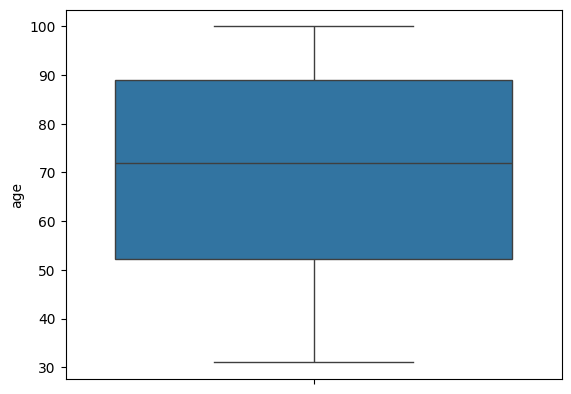

In [52]:
sns.boxplot(df_patient['age'])
plt.show()

Don't have outliner in age

In [53]:
bins   = [18, 45, 65, np.inf]
labels = ['Adult', 'Middle Age', 'Senior']

df_patient['age_group'] = pd.cut(df_patient['age'], bins=bins, labels=labels)

df_patient['age_group'].value_counts()

,count
age_group,
Senior,576
Middle Age,243
Adult,155


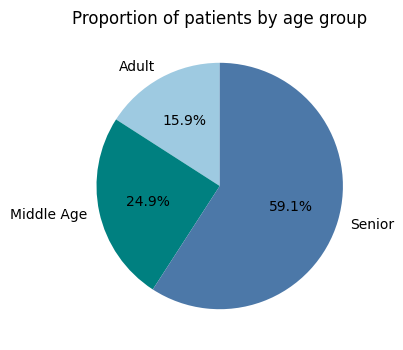

In [54]:
counts = df_patient['age_group'].value_counts().reindex(['Adult', 'Middle Age', 'Senior'])
counts.plot.pie(autopct='%1.1f%%',startangle=90,colors=['#9ecae1', 'teal', '#4c78a8'],figsize=(4, 4))
plt.title('Proportion of patients by age group')
plt.ylabel('')
plt.show()

eniors make up the clear majority of the patients, accounting for 59.1% of the total.

###  Top 5 Cities by Patient Count


In [55]:
top_5_cities = df_patient['CITY'].value_counts().head(5).reset_index()
top_5_cities

,CITY,count
0,Boston,541
1,Quincy,80
2,Cambridge,45
3,Revere,42
4,Chelsea,39


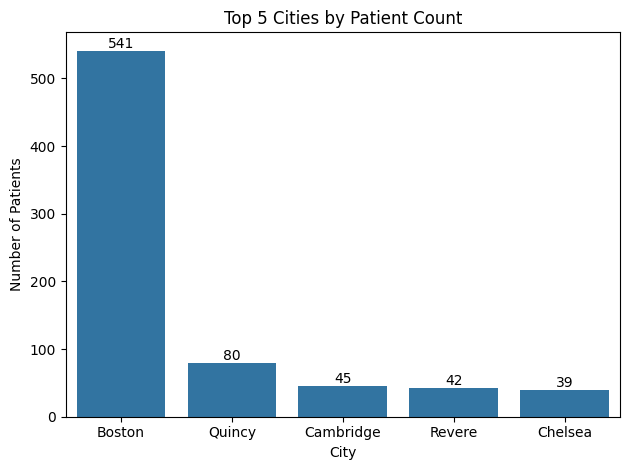

In [56]:
a = sns.barplot(top_5_cities,x = 'CITY', y='count')
for i in a.containers:
  a.bar_label(i)
plt.title('Top 5 Cities by Patient Count')
plt.ylabel('Number of Patients')
plt.xlabel('City')
plt.tight_layout()
plt.show()

The highest number of patients come from Boston, which is expected since the hospital is located within the same city.

In [57]:
df_patient.head()

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,age,age_group
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaT,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,...,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503,45,Adult
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaT,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,...,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162,82,Senior
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaT,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,...,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085,64,Middle Age
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,...,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801,94,Senior
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,...,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813,94,Senior


### Patient Demographics (Marital Status, Race, Ethnicity, Gender)


<IPython.core.display.Javascript object>

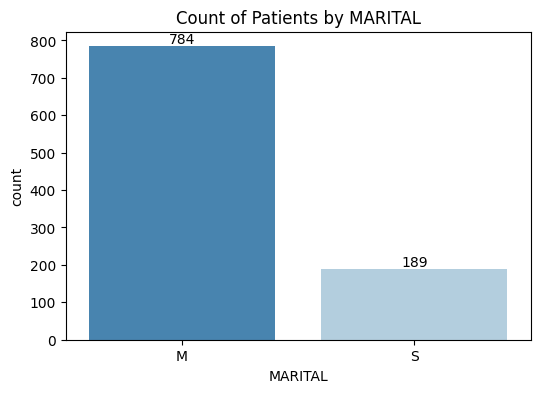

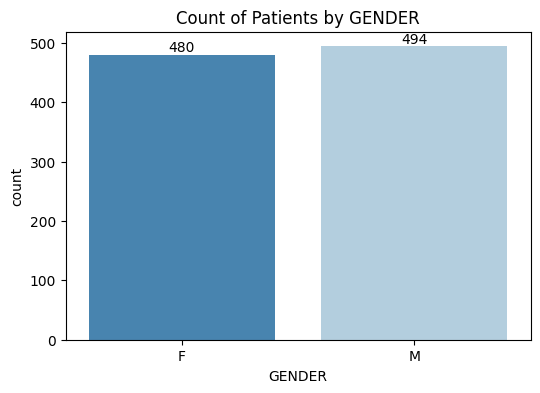

In [58]:
from google.colab import output
output.no_vertical_scroll()

cat_patient_cols = ['MARITAL', 'GENDER']

for col in cat_patient_cols:
    plt.figure(figsize=(6, 4))
    a = sns.countplot(data=df_patient, x=col, palette='Blues_r')
    for j in a.containers:
      a.bar_label(j)
    plt.title(f'Count of Patients by {col}')
    plt.show()

- Most patients are married.
- There is an almost equal number of male and female patients.

In [59]:
df_procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02 09:26:36+00:00,2011-01-02 12:58:36+00:00,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03 05:44:39+00:00,2011-01-03 06:01:42+00:00,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04 14:49:55+00:00,2011-01-04 15:04:55+00:00,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05 04:02:09+00:00,2011-01-05 04:17:09+00:00,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05 12:58:36+00:00,2011-01-05 16:42:36+00:00,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN


In [60]:
df_procedures['BASE_COST'].sum()

np.int64(105517711)

In [61]:
df_encounter.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,YEAR,duration_hours,duration_category,is_zero_coverage
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02 09:26:36+00:00,2011-01-02 12:58:36+00:00,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN,2011,3.53,under 24 hours,Zero Coverage
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03 05:44:39+00:00,2011-01-03 06:01:42+00:00,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN,2011,0.28,under 24 hours,Zero Coverage
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03 14:32:11+00:00,2011-01-03 14:47:11+00:00,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN,2011,0.25,under 24 hours,Has Coverage
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03 16:24:45+00:00,2011-01-03 16:39:45+00:00,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN,2011,0.25,under 24 hours,Zero Coverage
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03 17:36:53+00:00,2011-01-03 17:51:53+00:00,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia,2011,0.25,under 24 hours,Zero Coverage


### Key Insights

- Most patients are local seniors from Boston coming in for short, same-day outpatient visits (under 24 hours).
- 69% of total costs (\$70.4M) are unclaimed, heavily driven by nearly half of all visits (48.7%) having zero insurance coverage.
- Electrical cardioversion creates massive financial exposure due to both a high base cost (\$25.9k) and high frequency (1,383 procedures).
- Nearly half (48%) of discharged inpatient visits result in a readmission within 30 days.

---

### Recommendations

- Set up on-site financial counseling to help uninsured patients qualify for Medicaid or financial aid to recover part of the $70M+ in unclaimed costs.
- Implement senior-focused post-discharge check-ins and care plans to lower the 48% 30-day return rate.
- Review contracts and clinical pathways for electrical cardioversion and renal dialysis to better control large procedure expenses.
- Align hospital staffing and resources around ambulatory and outpatient services, which make up the vast majority of patient demand.
- Boston and the neighbouring cities (Quincy, Cambridge, Revere, Chelsea) supply most patients, so community clinics and partnerships there will have the greatest reach.
- Control ICU and surgical cost drivers. Introduce utilisation review and standard pathways for ICU admission, bypass surgery and cardioversion, and track their cost variance.